In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import sys

root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

import torch
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_trainer.model_utils import SparseAutoencoder
from sae_trainer.feature_tracer_utils import FeatureTracer, TraceConfig
from sae_trainer.feature_tracer_eval_utils import top_n_feats_by_hits_count, top_n_feats_by_act_mass, prompt_x_feature_heatmap, feature_token_position_profile, top_m_feature_coactivation, render_feature_card

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm = AutoModelForCausalLM.from_pretrained(model_name).to(device).eval()

# Load SAE checkpoint — pick whichever layer you want to analyse (3, 6, 9, or 11)
ckpt = torch.load("sae_gpt2_layer3.pt", map_location=device)
sae = SparseAutoencoder(d_in=ckpt["d_in"], d_latent=ckpt["d_latent"], normalize_decoder=True).to(device)
sae.load_state_dict(ckpt["model_state"])
sae.eval()

SparseAutoencoder(
  (encoder): Linear(in_features=768, out_features=6144, bias=True)
  (decoder): Linear(in_features=6144, out_features=768, bias=False)
)

In [4]:
# 4) Tracer config — layer_idx MUST match the checkpoint loaded above
cfg = TraceConfig(
    layer_idx=3,
    topk_per_token=8,
    min_activation=0.01,
    max_new_tokens=10,
    do_sample=True,
    temperature=0.7,
)
tracer = FeatureTracer(llm, tokenizer, sae, device, cfg)

In [5]:
# 5) Run tracing
#summaries = tracer.trace_prompts([
#    "Explain sparse autoencoders in simple terms.",
#    "Write a short poem about Paris and geometry.",
#    "Why do transformers use attention?"
#])
summaries = tracer.trace_prompts(
    [
        "Q: My name is Miles. What is my name?\nA:",
        "Q: My name tag says Miles. What is my name?\nA:",
        "Q: My friend told me: 'Miles, come here and see this!'. What is my name?\nA:"
    ],
    system_prompt=None #GPT-2 has no chat template, so system prompt would just be appended as plain text. Would be more useful for more complex models
)
summaries

[{'prompt_id': 'p0',
  'prompt': 'Q: My name is Miles. What is my name?\nA:',
  'generated_text': 'Q: My name is Miles. What is my name?\nA: My name is Miles. What is my name?',
  'num_prompt_tokens': 15,
  'num_tokens': 25,
  'num_hits': 72},
 {'prompt_id': 'p1',
  'prompt': 'Q: My name tag says Miles. What is my name?\nA:',
  'generated_text': 'Q: My name tag says Miles. What is my name?\nA: Miles is my nickname for a year and a half',
  'num_prompt_tokens': 16,
  'num_tokens': 26,
  'num_hits': 72},
 {'prompt_id': 'p2',
  'prompt': "Q: My friend told me: 'Miles, come here and see this!'. What is my name?\nA:",
  'generated_text': "Q: My friend told me: 'Miles, come here and see this!'. What is my name?\nA: I am Tom.\nQ: What is your",
  'num_prompt_tokens': 26,
  'num_tokens': 36,
  'num_hits': 72}]

In [6]:
# 6) Inspect
df = tracer.to_dataframe()
display(df.head())

display(tracer.top_features(20))

# replace with a real feature id from top_features output
#display(tracer.feature_contexts(feature_id=int(tracer.top_features(1).iloc[0]["feature_id"]), top_n=10))

#tracer.save_csv("feature_hits.csv")

,prompt_id,prompt,generated_text,token_pos,token,feature_id,activation
0,p0,Q: My name is Miles. What is my name?\nA:,Q: My name is Miles. What is my name?\nA: My n...,15,ĠMy,4229,3.581305
1,p0,Q: My name is Miles. What is my name?\nA:,Q: My name is Miles. What is my name?\nA: My n...,15,ĠMy,2156,3.380685
2,p0,Q: My name is Miles. What is my name?\nA:,Q: My name is Miles. What is my name?\nA: My n...,15,ĠMy,5605,3.359373
3,p0,Q: My name is Miles. What is my name?\nA:,Q: My name is Miles. What is my name?\nA: My n...,15,ĠMy,5808,3.310114
4,p0,Q: My name is Miles. What is my name?\nA:,Q: My name is Miles. What is my name?\nA: My n...,15,ĠMy,1747,3.181689


,feature_id,hits,mean_activation,max_activation
0,736,14,3.671251,4.163966
1,598,13,3.226773,4.236177
2,870,11,3.492203,4.232354
3,4811,6,3.346389,3.847781
4,4229,5,3.242280,3.581305
5,4086,4,3.820609,4.612335
6,1864,4,3.518603,4.145926
7,1470,4,3.382114,3.668902
8,1332,3,4.193406,4.710489
9,2385,3,3.962189,4.670340


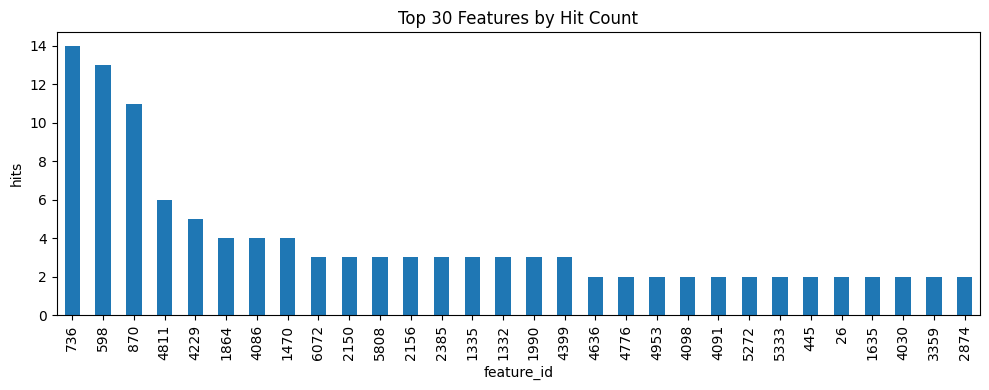

In [30]:
top_n_feats_by_hits_count(tracer)

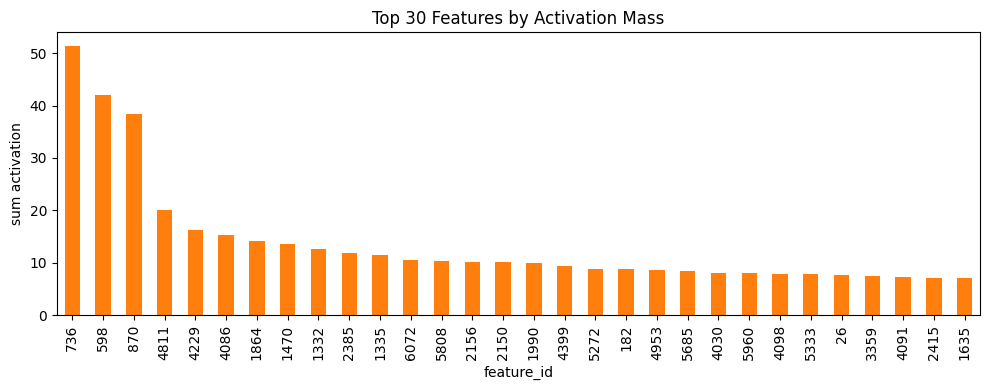

In [31]:
top_n_feats_by_act_mass(tracer)

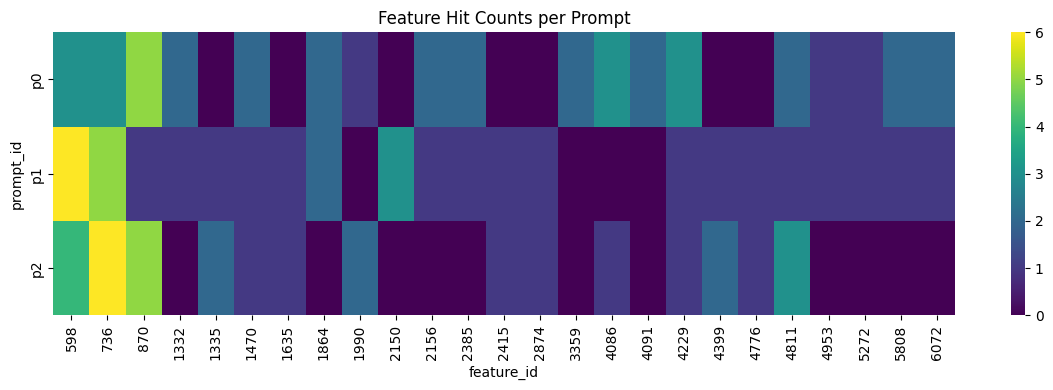

In [32]:
prompt_x_feature_heatmap(tracer)

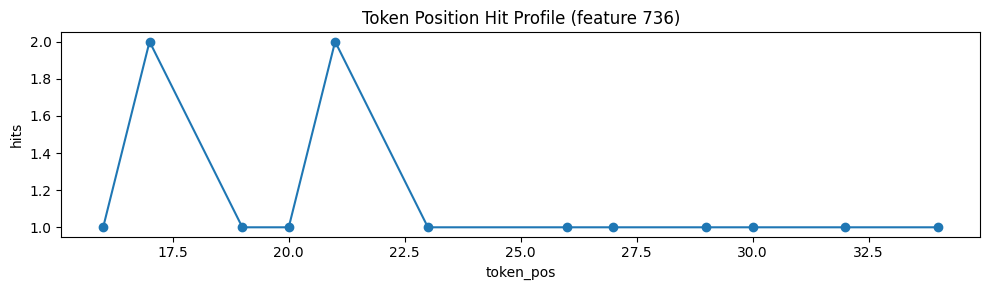

In [33]:
feature_token_position_profile(tracer)

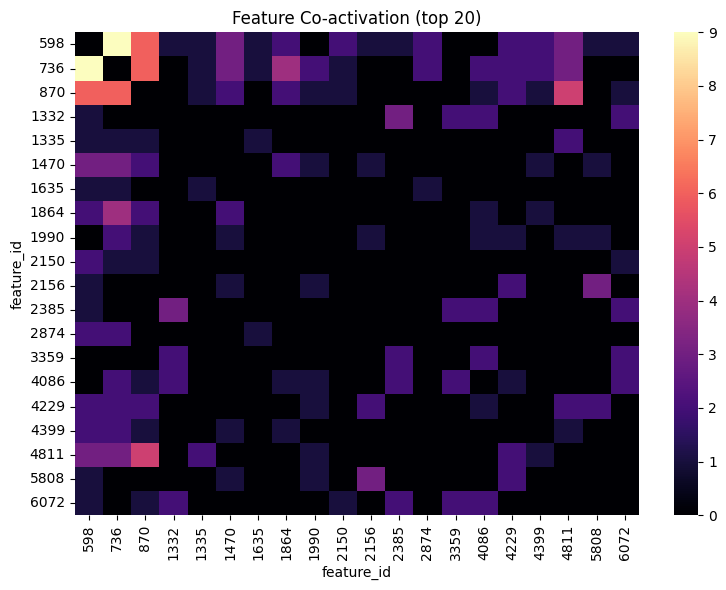

In [34]:
top_m_feature_coactivation(tracer)

In [35]:
# Render cards for top 5 features across all tokens (no filter)
top = tracer.top_features(5)
for fid in top["feature_id"]:
    render_feature_card(int(fid), tracer)

NameError: name 'html_lib' is not defined

In [20]:
# Explore which positions "Miles" appears at
tracer.token_positions(["Miles"])

,prompt_id,token_pos,token
0,p0,18,ĠMiles
1,p1,16,ĠMiles


In [21]:
# Top features active only when "Miles" is generated
tracer.top_features(20, tokens=["Miles"])

,feature_id,hits,mean_activation,max_activation
0,5272,2,4.388100,4.427247
1,182,2,4.361388,4.487702
2,4953,2,4.313571,4.490234
3,5685,1,4.367739,4.367739
4,870,1,4.232354,4.232354
5,2206,1,4.168621,4.168621
6,736,1,4.163966,4.163966
7,1864,1,4.145926,4.145926
8,2371,1,4.127650,4.127650
9,5333,1,4.122332,4.122332


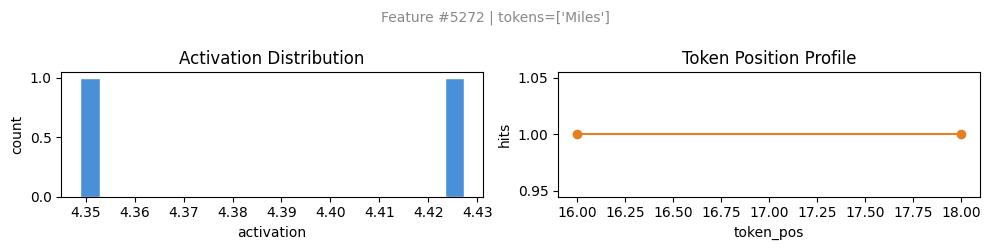

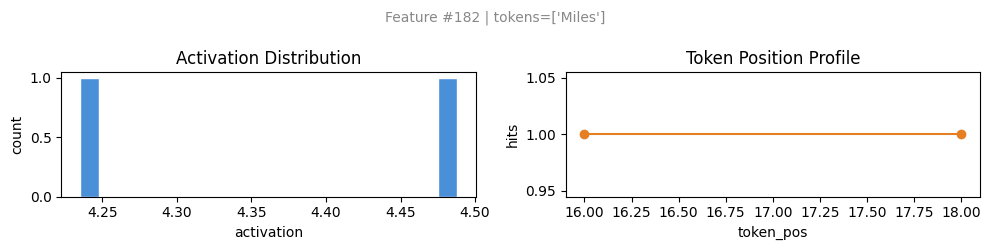

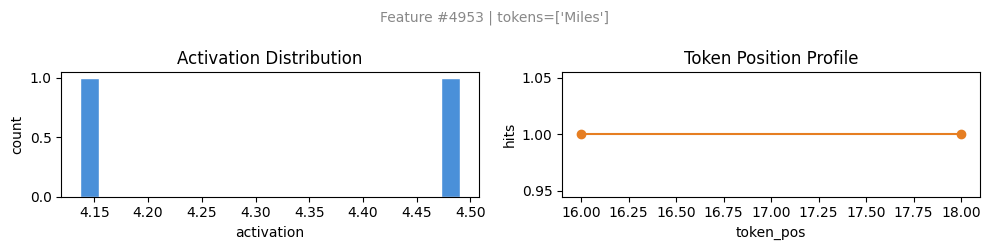

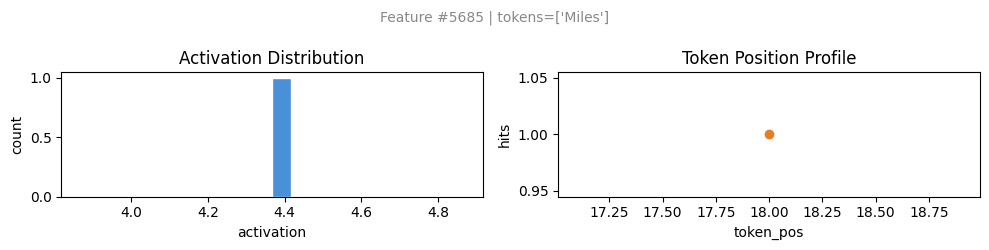

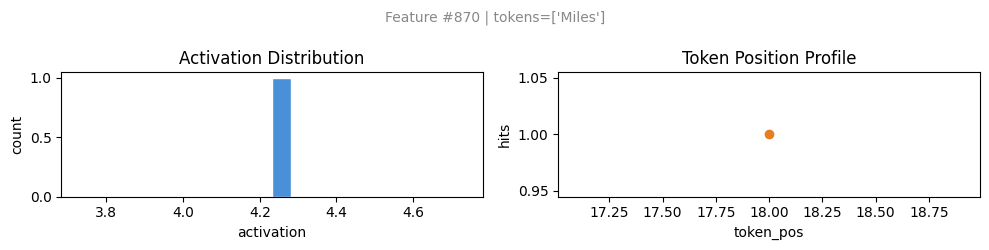

In [ ]:
# Render cards scoped to "Miles" token
# There seem to be a few features that are firing on the correct answer!
# 5272 - Firing on 'Miles' in prompt 1. Also fires weakly on 'Miles' in prompt 2
# 182 - Primary feature firing on 'Miles' in prompt 2. Also firest weakly on 'Miles' in prompt 1
# 4953 - Also fires on 'Miles' in prompt 1 and weakly in prompt 2.
# None of them fire on 'Tom' in prompt 3, when it gives the wrong answer.
# Next: what features do fire on 'Tom'??
top = tracer.top_features(5, tokens=["Miles"])
for fid in top["feature_id"]:
    render_feature_card(int(fid), tracer, tokens=["Miles"])

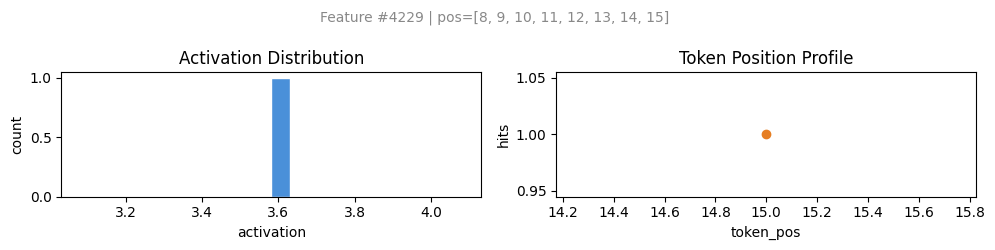

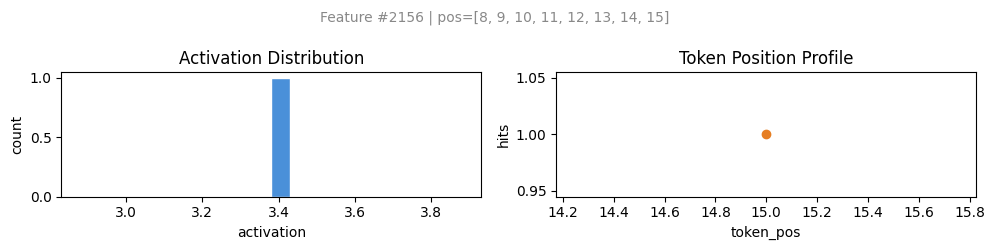

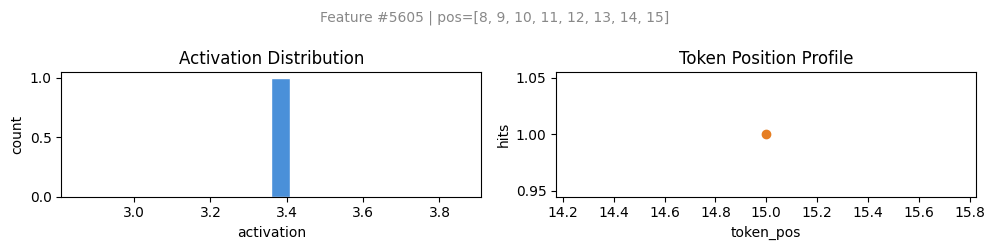

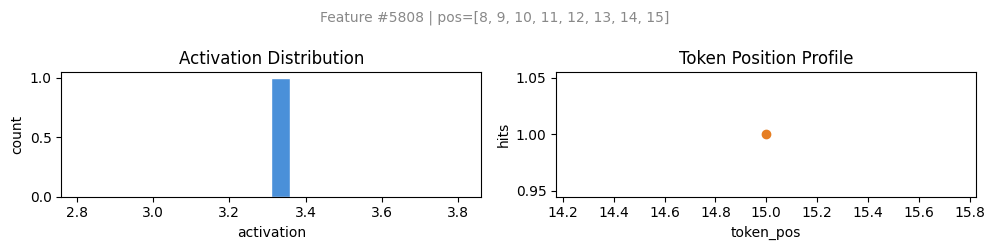

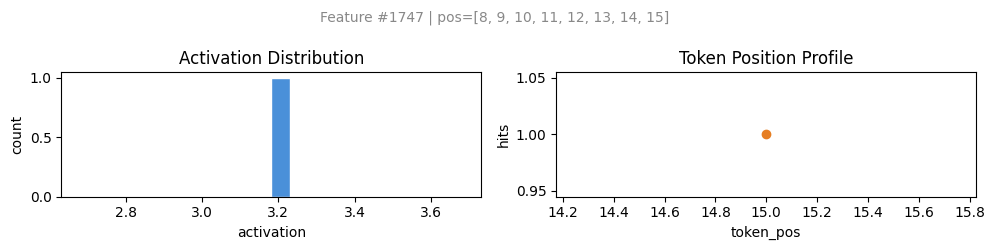

In [24]:
# Render cards scoped to a position range (e.g. answer tokens only)
top = tracer.top_features(5, token_pos=list(range(8, 16)))
for fid in top["feature_id"]:
    render_feature_card(int(fid), tracer, token_pos=list(range(8, 16)))

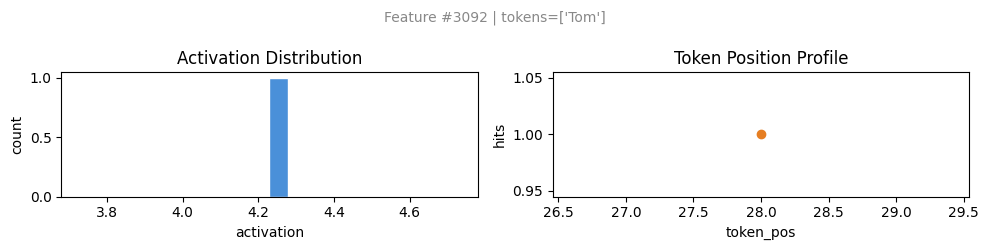

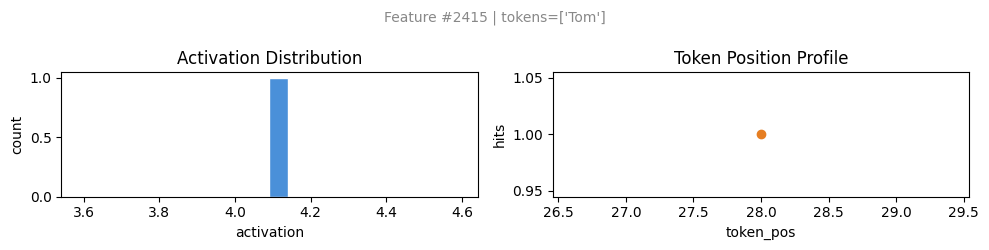

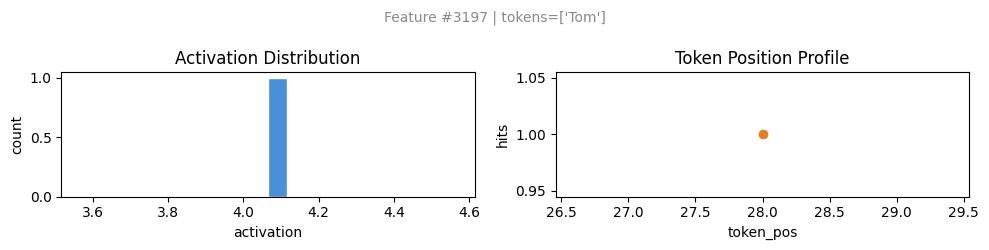

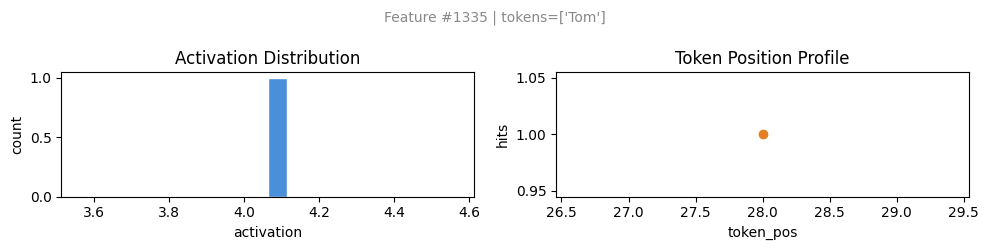

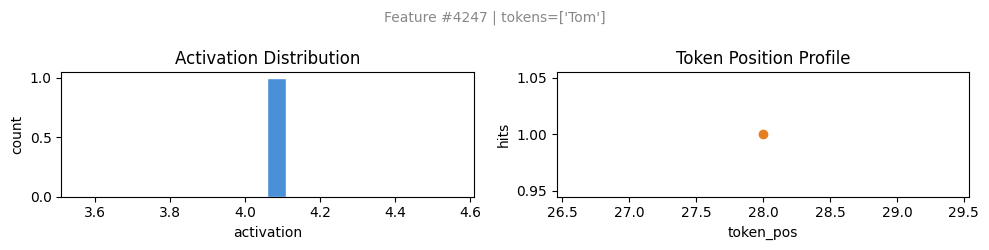

In [25]:
top = tracer.top_features(5, tokens=["Tom"])
for fid in top["feature_id"]:
    render_feature_card(int(fid), tracer, tokens=["Tom"])

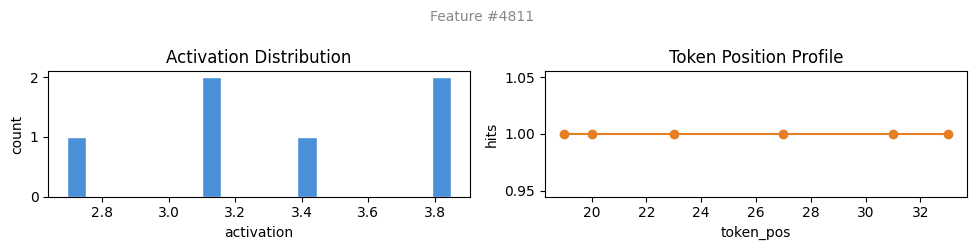

In [26]:
render_feature_card(4811, tracer)